In [43]:
import pandas as pd

# Load the dataset
file_path = "Measles_Line_List_2022_to_2025.xlsx"
measles_df = pd.read_excel(file_path)

# Quick overview
print("Shape of dataset:", measles_df.shape)
print("\nColumn names:\n", measles_df.columns)

# Peek at the first few rows
measles_df.head()

# Summary of missing values
measles_df.isnull().sum()

# Basic descriptive statistics
measles_df.describe(include='all')


Shape of dataset: (83436, 22)

Column names:
 Index(['ID number', 'Name of patient', 'Age (years)', 'Age (months)', 'Sex',
       'Outcome', 'Region', 'Zone', 'Wereda', 'HF_Name', 'Dateof onset',
       'Date Seen at Health facility', 'Date specimen collected',
       'DateLab Sent Out results', 'Measles Vx Dose', 'Specimen condition',
       'Data Tyep', 'Measles IgM', 'Rubella IgM', 'FC', 'WEEK ONSET',
       'MONTH ONSET'],
      dtype='object')


,ID number,Name of patient,Age (years),Age (months),Sex,Outcome,Region,Zone,Wereda,HF_Name,...,Date specimen collected,DateLab Sent Out results,Measles Vx Dose,Specimen condition,Data Tyep,Measles IgM,Rubella IgM,FC,WEEK ONSET,MONTH ONSET
count,83436,82311,83111.000000,65980.000000,82636,83436,83436,83436,83436,76793,...,22559,44444,82801.000000,83436.000000,83436,83436.000000,83345.000000,83436.000000,83436.000000,83436
unique,83408,77731,NaN,NaN,11,5,20,226,1449,8443,...,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,12
top,ETH-ORO-WSH-25-2027,MOHAMMED ALI,NaN,NaN,M,Alive,Oromia,West Omo,Menit Goldiye,Chebera HC,...,NaN,NaN,NaN,NaN,Line-list,NaN,NaN,NaN,NaN,Mar
freq,2,18,NaN,NaN,26266,55460,27429,6887,3357,1191,...,NaN,NaN,NaN,NaN,60804,NaN,NaN,NaN,NaN,12620
mean,NaN,NaN,7.222101,5.872245,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-09-15 07:36:54.832217856,2023-07-14 20:25:20.871208704,28.337677,6.833070,NaN,7.055635,7.299946,2.307721,22.732178,NaN
min,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2022-01-01 00:00:00,2002-03-03 00:00:00,0.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN
25%,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2022-11-21 00:00:00,2022-12-12 00:00:00,0.000000,1.000000,NaN,2.000000,4.000000,2.000000,9.000000,NaN
50%,NaN,NaN,4.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-07-25 00:00:00,2023-09-12 00:00:00,1.000000,9.000000,NaN,9.000000,9.000000,2.000000,19.000000,NaN
75%,NaN,NaN,9.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-06-11 00:00:00,2023-12-17 00:00:00,99.000000,9.000000,NaN,9.000000,9.000000,2.000000,37.000000,NaN
max,NaN,NaN,80.000000,896.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2025-11-18 00:00:00,2025-11-20 00:00:00,99.000000,9.000000,NaN,9.000000,9.000000,5.000000,53.000000,NaN


In [44]:
#Outcome variable check
measles_df['Outcome'].value_counts(normalize=True) * 100

Outcome
Alive    66.470109
1        32.941416
Dead      0.311616
2         0.198955
Died      0.077904
Name: proportion, dtype: float64

In [45]:
# Standardize outcome coding
def recode_outcome(val):
    if str(val).strip().lower() in ['dead', 'died', '2']:
        return 'Dead'
    elif str(val).strip().lower() in ['alive', '1']:
        return 'Alive'
    else:
        return 'Unknown'

measles_df['Outcome_clean'] = measles_df['Outcome'].apply(recode_outcome)
# Encode Alive = 0, Dead = 1
measles_df['Outcome_binary'] = measles_df['Outcome_clean'].map({'Alive':0, 'Dead':1})
# Check distribution
print(measles_df['Outcome_binary'].value_counts(normalize=True) * 100)
print(measles_df['Outcome_clean'].value_counts(normalize=True) * 100)

Outcome_binary
0    99.411525
1     0.588475
Name: proportion, dtype: float64
Outcome_clean
Alive    99.411525
Dead      0.588475
Name: proportion, dtype: float64


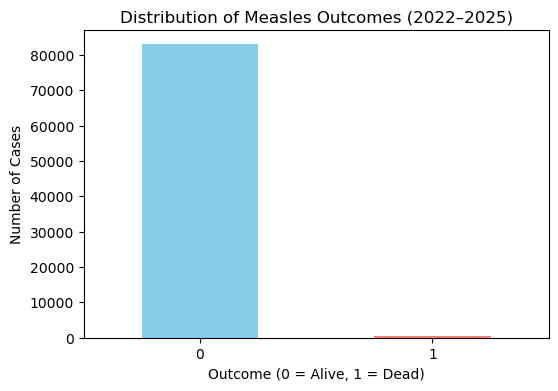

Outcome_binary
0    82945
1      491
Name: count, dtype: int64


In [46]:
import matplotlib.pyplot as plt

# Count of Alive (0) vs Dead (1)
outcome_counts = measles_df['Outcome_binary'].value_counts()

# Plot
plt.figure(figsize=(6,4))
outcome_counts.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribution of Measles Outcomes (2022–2025)")
plt.xlabel("Outcome (0 = Alive, 1 = Dead)")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.show()

# Print counts for reference
print(outcome_counts)

In [47]:
import numpy as np

# Clean age variables
measles_df['Age_years'] = pd.to_numeric(measles_df['Age (years)'], errors='coerce')
measles_df['Age_months'] = pd.to_numeric(measles_df['Age (months)'], errors='coerce')

# Fill missing Age_years with Age_months/12 if available
measles_df['Age_final'] = measles_df['Age_years']
measles_df.loc[measles_df['Age_final'].isna() & measles_df['Age_months'].notna(), 'Age_final'] = measles_df['Age_months'] / 12

print(measles_df['Age_final'].describe())
print("Missing ages:", measles_df['Age_final'].isna().sum())


count    83133.000000
mean         7.220256
std          8.214965
min          0.000000
25%          2.000000
50%          4.000000
75%          9.000000
max         80.000000
Name: Age_final, dtype: float64
Missing ages: 303


median age: 4.0
count    83436.000000
mean         7.208562
std          8.202323
min          0.000000
25%          2.000000
50%          4.000000
75%          9.000000
max         80.000000
Name: Age_final_imputed, dtype: float64
Outcome_binary      0    1   CFR (%)
Age_group                           
<1 year         16776  152  0.897921
1–4 years       32370  221  0.678101
5–14 years      22613   74  0.326178
15+ years       11186   44  0.391808


C:\Users\HP\AppData\Local\Temp\ipykernel_26084\314500708.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_outcome = measles_df.groupby('Age_group')['Outcome_binary'].value_counts().unstack().fillna(0)


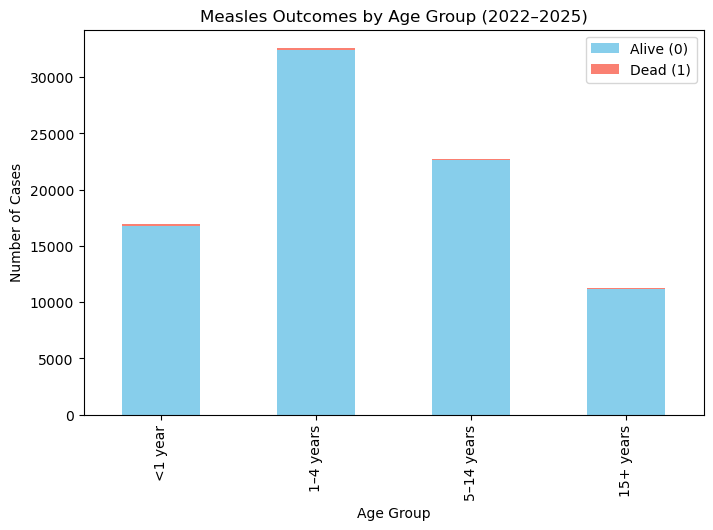

In [48]:
median_age = measles_df['Age_final'].median()
print("median age:",median_age)
measles_df['Age_final_imputed'] = measles_df['Age_final'].fillna(median_age)

print(measles_df['Age_final_imputed'].describe())

# Define age groups
bins = [-1, 1, 5, 15, 100]
labels = ['<1 year', '1–4 years', '5–14 years', '15+ years']
measles_df['Age_group'] = pd.cut(measles_df['Age_final_imputed'], bins=bins, labels=labels)

# Calculate CFR by age group
age_outcome = measles_df.groupby('Age_group')['Outcome_binary'].value_counts().unstack().fillna(0)
age_outcome['CFR (%)'] = (age_outcome[1] / (age_outcome[0] + age_outcome[1])) * 100

print(age_outcome)
# Plot
age_outcome[[0,1]].plot(kind='bar', stacked=True, figsize=(8,5), color=['skyblue','salmon'])
plt.title("Measles Outcomes by Age Group (2022–2025)")
plt.xlabel("Age Group")
plt.ylabel("Number of Cases")
plt.legend(["Alive (0)", "Dead (1)"])
plt.show()

In [49]:
print(measles_df['Sex'].unique())
print(measles_df['Measles Vx Dose'].unique())
print(measles_df['Region'].unique())
print(measles_df['Sex'].value_counts(dropna=False))
print(measles_df['Measles Vx Dose'].value_counts(dropna=False))

[1 2 nan 9 'F' 'M' 'f' 'm' '6' '8' '7' '5']
[ 0. 99.  1. nan  2.  3.  4.  9.  5.  7. 10.]
['South West Ethiopia' 'Addis Ababa' 'Amhara' 'Oromia' 'Central Ethiopia'
 'Somali' 'Benshangul Gumuz' 'Dire Dawa' 'Tigray' 'Afar' 'South Ethiopia'
 'AMHARA' 'Sidama' 'Hareri' 'Gambella' 'OROMIA' 'SNNPR' 'South West'
 'Benishangul Gumuz' 'DIre Dawa']
Sex
M      26266
F      24102
1      16779
2      15464
NaN      800
m          9
f          8
9          2
6          2
5          2
8          1
7          1
Name: count, dtype: int64
Measles Vx Dose
0.0     28143
1.0     25685
99.0    23323
2.0      5376
NaN       635
3.0       239
9.0        20
4.0         7
5.0         5
7.0         2
10.0        1
Name: count, dtype: int64


In [50]:
sex_map = {
    1: 'Male', 'M': 'Male', 'm': 'Male',
    2: 'Female', 'F': 'Female', 'f': 'Female'
}
measles_df['Sex_clean'] = measles_df['Sex'].map(sex_map).fillna('Unknown')

# Handle numeric miscoded entries
measles_df.loc[measles_df['Sex'].isin([5,6,7,8,9]), 'Sex_clean'] = 'Unknown'

print(measles_df['Sex_clean'].value_counts())
print(measles_df['Sex_clean'].describe())


Sex_clean
Male       43054
Female     39574
Unknown      808
Name: count, dtype: int64
count     83436
unique        3
top        Male
freq      43054
Name: Sex_clean, dtype: object


In [51]:
def recode_vx(val):
    if val in [0]:
        return 'Not vaccinated'
    elif val in [1,2,3]:
        return 'Vaccinated'
    elif val in [99]:
        return 'Unknown'
    elif pd.isna(val):
        return 'Unknown'
    else:
        return 'Unknown'  # catch 4,5,7,9,10

measles_df['Vx_status'] = measles_df['Measles Vx Dose'].apply(recode_vx)

print(measles_df['Vx_status'].value_counts())
print(measles_df['Vx_status'].describe())

Vx_status
Vaccinated        31300
Not vaccinated    28143
Unknown           23993
Name: count, dtype: int64
count          83436
unique             3
top       Vaccinated
freq           31300
Name: Vx_status, dtype: object


In [52]:
region_map = {
    'AMHARA':'Amhara',
    'OROMIA':'Oromia',
    'Benishangul Gumuz':'Benshangul Gumuz',
    'Benshangul Gumuz':'Benshangul Gumuz',
    'DIre Dawa':'Dire Dawa',
    'South West':'South West Ethiopia'
}
measles_df['Region_clean'] = measles_df['Region'].replace(region_map)

print(measles_df['Region_clean'].value_counts())
print(measles_df['Region_clean'].describe())
# Mortality counts by region
region_outcome = measles_df.groupby('Region_clean')['Outcome_binary'].value_counts().unstack().fillna(0)

# Calculate CFR (%)
region_outcome['CFR (%)'] = (region_outcome[1] / (region_outcome[0] + region_outcome[1])) * 100

print(region_outcome.sort_values('CFR (%)', ascending=False))


Region_clean
Oromia                 27431
South West Ethiopia    10656
Amhara                 10058
Somali                  6366
Addis Ababa             6050
SNNPR                   5724
South Ethiopia          4842
Sidama                  3926
Benshangul Gumuz        2480
Central Ethiopia        2313
Gambella                1453
Tigray                   838
Afar                     787
Dire Dawa                349
Hareri                   163
Name: count, dtype: int64
count      83436
unique        15
top       Oromia
freq       27431
Name: Region_clean, dtype: object
Outcome_binary           0    1   CFR (%)
Region_clean                             
Gambella              1414   39  2.684102
Benshangul Gumuz      2414   66  2.661290
Afar                   770   17  2.160102
Somali                6252  114  1.790763
Central Ethiopia      2296   17  0.734976
Hareri                 162    1  0.613497
Tigray                 834    4  0.477327
Amhara               10011   47  0.467290
Sida

Outcome_binary      0    1   CFR (%)
Sex_clean                           
Female          39316  258  0.651943
Male            42827  227  0.527245
Unknown           802    6  0.742574


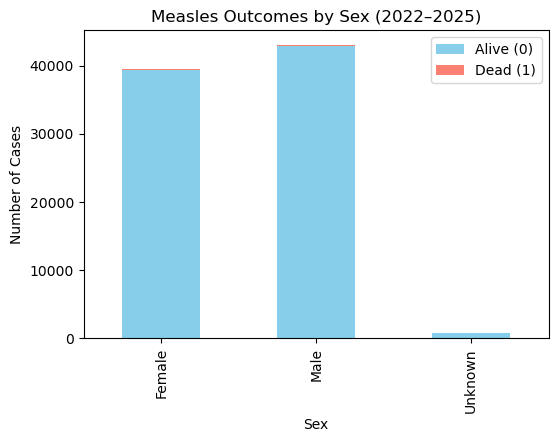

In [53]:
#sex-stratified CFR:
# Mortality counts by sex
sex_outcome = measles_df.groupby('Sex_clean')['Outcome_binary'].value_counts().unstack().fillna(0)

# Calculate CFR (%)
sex_outcome['CFR (%)'] = (sex_outcome[1] / (sex_outcome[0] + sex_outcome[1])) * 100

print(sex_outcome)

# Plot
sex_outcome[[0,1]].plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue','salmon'])
plt.title("Measles Outcomes by Sex (2022–2025)")
plt.xlabel("Sex")
plt.ylabel("Number of Cases")
plt.legend(["Alive (0)", "Dead (1)"])
plt.show()

Outcome_binary      0    1   CFR (%)
Vx_status                           
Not vaccinated  27834  309  1.097964
Unknown         23907   86  0.358438
Vaccinated      31204   96  0.306709


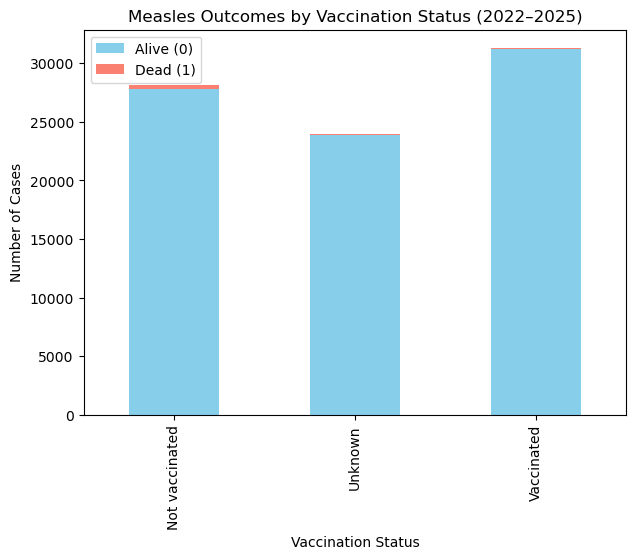

In [54]:
# Mortality counts by vaccination status
vx_outcome = measles_df.groupby('Vx_status')['Outcome_binary'].value_counts().unstack().fillna(0)

# Calculate CFR (%)
vx_outcome['CFR (%)'] = (vx_outcome[1] / (vx_outcome[0] + vx_outcome[1])) * 100

print(vx_outcome)

# Plot
vx_outcome[[0,1]].plot(kind='bar', stacked=True, figsize=(7,5), color=['skyblue','salmon'])
plt.title("Measles Outcomes by Vaccination Status (2022–2025)")
plt.xlabel("Vaccination Status")
plt.ylabel("Number of Cases")
plt.legend(["Alive (0)", "Dead (1)"])
plt.show()

In [55]:
#recategorize facilities into Hospital, Health Center, Health Post, Unknown
#this variable needs a two‑stage cleaning process rather than a simple keyword match. Because of the manual entry, there are ambiguous cases (like Tula PH, Angela PHCU, Woreda RRT, NOAH Specialty Clinic) that require expert judgment.
def recode_facility(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).lower()
    if 'hospital' in val or 'ho' in val:
        return 'Hospital'
    elif 'h/center' in val or 'HEATH CENTER' in val or 'HEALTH CNTER' in val or'H/CENETR' in val or 'H/C' in val or 'hc' in val or 'health center' in val or 'health centre' in val or 'phcu' in val or 'clinic' in val:
        return 'Health Center'
    elif 'health post' in val or 'hp' in val or 'rrt' in val:
        return 'Health Post'
    else:
        return 'Unclassified'  # temporary bucket for ambiguous cases

measles_df['Facility_type'] = measles_df['HF_Name'].apply(recode_facility)
#Inspect Remaining “Unclassified” Values
unclassified = measles_df.loc[measles_df['Facility_type'] == 'Unclassified', 'HF_Name'].unique()
print(unclassified[:100])  # show first 50 for inspection

['PHILIPOSE H/CENETR' 'NOAH SPECIALITY CENTER' 'HARO HEATH CENTER'
 'DR.KALID SPECIALIZED MEDICAL CENTER' 'Wenbera' 'Bekalu Alemenw' 'GUCSH'
 'Dangila PH' 'KULAY H/POST' 'BEEAR HEALH CENTER' 'MENGE HEALTH CNTER'
 'AXUM HALTH CENTER' 'HAMUSIT HEALTHN CENTER' 'AMBOBER HEALTHN CENTER'
 'DAGIM HEDASE HEATH CENTER' 'HUDET HEATLH CENTER' 'NOAH SPECALITY CENTER'
 ',2-' 'DANEMA HEALTH CENTE' 'YADOTA HEALTH CENTE' 'B/B/M/TIC' '0707'
 'HADALE HALTH CENTER' 'ARGADA HARO DINTU H/C' 'TARATO H/C'
 'BOKE GUDO H/C' 'BOKE GIDO H/C' 'DANEMA H/C' 'AYYALE H/C' 'BUTAJIRA H/C'
 'NIFASE SILK  LAFTO W01 H/C' 'NIFAS SILK LAFTO  W-2 H/C'
 'KOLFE KERANIYO W-3 H/C' 'UKE H/C' 'LIDETA W-04 H/C' 'ADELE CACHEMENT'
 'GEBA KEMISE H/C' 'SILITANA H/C' 'MIKILAND H/C' 'ADIHALIT KEBELE'
 'ABENET H/C' 'KASSANCHESH/C' 'ADDIS KETEMA W-3 H/C'
 'NIFAS SILK LAFTO W2 H/C' 'KARO DADE H/C' 'GORO H/C'
 'HACHALU HUNDESA H/C' 'WADERA H/ENTER' 'GOLOLCHA H/C' 'GOLOLCHE H/C'
 'GOLOCHE H/C' 'GOLOCHA H/C' 'KOKA H/C' 'KOLFE KERANIYO W-03 H/C

In [56]:
import re
#Master Facility Registry (MFR): Ethiopia’s official health facility database is used for cleaning and standardizing facility names in your dataset.
def recode_facility(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).lower().strip()
    val = re.sub(r'[^a-z0-9 ]', '', val)  # remove punctuation for consistency
    if 'hospital' in val or 'hiwot fana' in val or 'aurh' in val or 'mada  welabu' in val or 'mwoh' in val or 'ospital' in val or 'tuth' in val or 'huth' in val or 'ho' in val or 'university' in val or 'hfsuh' in val or 'h.f.s.u.h' in val or 'colleage' in val or 'hsp' in val or 'hosp' in val or 'ph' in val or 'p/ho' in val or 'gh' in val or 'sho' in val or 'csh' in val or 'pho' in val:
        return 'Hospital'
    elif ('hc' in val or 'h/center' in val or 'wadera henter' in val or 'abaye taka' in val or 'kmagane' in val or 'eliwuha' in val or 'awaraa' in val or 'awara' in val or 'shelo balela' in val or 'dambobi  robale' in val or 'gabissa' in val or 'mogissa' in val or 'adje' in val or 'anger' in val or 'ilu harar' in val or 'chewaka' in val or 'berek' in val or 'berka' in val or 'center' in val or 'health centar' in val or 'health cente' in val or 'specialized' in val or 'speciality' in val or 'specal' in val or
          'health centre' in val or 'millinium' in val or 'boneya' in val or 'health office' in val or 'akasha' in val or 'balla' in val or 'burra' in val or 'haro sabu' in val or 'dinsa' in val or 'krsttos semra' in val or 'dabaka dabobesa' in val or 'uke' in val or 'jegan' in val or 'melorasha' in val or 'senegal' in val or 'godora' in val or 'dita suluse' in val or 'omorate' in val or 'lugo' in val or 'wereda health office' in val or 'ceneter' in val or 'mc' in val or 'phcu' in val or 'clinic' in val or 'cilinic' in val or
          'mch' in val or 'sc' in val or 'gorche ketema' in val or 'masoya' in val or 'dch' in val or '3' in val or '2' in val or '1' in val or '0' in val or 'kkubi' in val or 'health facility' in val or 'h2' in val or 'h4' in val or 'wubhmer' in val or 'harawacha' in val or 'gorogudo' in val or 'chamo' in val or 'millitiary' in val or 'birsheleko' in val or 'halth center' in val or 'healtj center' in val or 'health center' in val or 'health cnter' in val or 'healthn center'in val or' heatlh center' in val or 'heath center' in val or 'healh center' in val):
        return 'Health Center'
    elif 'post' in val or 'idp' in val or 'yarinja' in val or 'toringole' in val or 'gazer' in val or 'lobet' in val or '01 hamus' in val or 'ipd' in val or 'acs team' in val or 'hshambara' in val or 'harsu wokilo' in val or  'degabarena' in val or 'gnimemery' in val or 'delegnimur' in val or 'gamaso kenera' in val or 'hubi' in val or 'hube' in val or 'bjima' in val or 'sahda' in val or 'adihalit kebele' in val or 'melekan' in val or 'mango' in val or 'community' in val or 'hp' in val or 'rrt' in val or 'refugee' in val or 'refuge' in val:
        return 'Health Post'
    else:
        return 'Unclassified'

measles_df['Facility_type'] = measles_df['HF_Name'].apply(recode_facility)
#Inspect Remaining “Unclassified” Values
unclassified = measles_df.loc[measles_df['Facility_type'] == 'Unclassified', 'HF_Name'].unique()
print(unclassified[:10])  # show first 50 for inspection
unclassified_count = (measles_df['Facility_type'] == 'Unclassified').sum()
print("Remaining Unclassified count:", unclassified_count)
# Frequency of each class
class_counts = measles_df['Facility_type'].value_counts()
 
print("Frequency of each class:")
print(class_counts)

['Wenbera' 'Bekalu Alemenw' 'B/B/M/TIC' 'ADELE CACHEMENT' 'Dakwaja'
 'Hamusa gebeya healte centare' 'kara Gumata' 'Haro Dimtu' 'U.TANKAKA'
 'U.TANKAKKA']
Remaining Unclassified count: 1685
Frequency of each class:
Facility_type
Health Center    44897
Hospital         22315
Health Post       7896
Unknown           6643
Unclassified      1685
Name: count, dtype: int64


In [57]:
# First apply your existing recode_facility function
measles_df['Facility_type'] = measles_df['HF_Name'].apply(recode_facility)

# Then apply the Addis Ababa rule:
# If region is Addis Ababa and facility is Unclassified, set to Health Center
mask = (
    (measles_df['Region_clean'].str.lower() == 'addis ababa') &
    (measles_df['Facility_type'] == 'Unclassified')
)
measles_df.loc[mask, 'Facility_type'] = 'Health Center'

# Frequency counts after refinement
class_counts = measles_df['Facility_type'].value_counts()
class_percent = measles_df['Facility_type'].value_counts(normalize=True) * 100

print("Frequency of each class:")
print(class_counts)

# Inspect remaining Unclassified
unclassified = measles_df.loc[measles_df['Facility_type'] == 'Unclassified', 'HF_Name'].unique()
print("\nRemaining Unclassified examples:", unclassified[:50])
print("Remaining Unclassified count:", (measles_df['Facility_type'] == 'Unclassified').sum())

Frequency of each class:
Facility_type
Health Center    44991
Hospital         22315
Health Post       7896
Unknown           6643
Unclassified      1591
Name: count, dtype: int64

Remaining Unclassified examples: ['Wenbera' 'Bekalu Alemenw' 'B/B/M/TIC' 'ADELE CACHEMENT' 'Dakwaja'
 'Hamusa gebeya healte centare' 'kara Gumata' 'Haro Dimtu' 'U.TANKAKA'
 'U.TANKAKKA' 'U/TANKAKA' 'B/Kuwe' 'Ching' 'CALLO' 'Yabitu koba' 'B/SHAN'
 'HALABA KULITO' 'TULU DIMTU' 'Biftu Siraro' 'Ajjee' 'S/shala' 'Ajee'
 'Ilaalaa' 'Aburee' 'Fandee' 'oree' 'Abure' 'Oree' 'ABURE' 'Ilala'
 'SAWELA' 'K/Kubbi' 's/shallaa' 'S/shallaa' 'S/shalla' 'Wabe' 'Silkamba'
 'Sunbura' 'Harbe Wolbato' 'Haro Shifa' 'Gorche Ketama' 'Haro shifa'
 'Tembel' 'shangama Bille' 'Shanko' 'Turmi' 'S/shall' 'BIFTU H/X'
 'Harawa - 4' 'BOKU SHANAN']
Remaining Unclassified count: 1591


In [58]:
# Filter all Unclassified facilities
unclassified = measles_df.loc[measles_df['Facility_type'] == 'Unclassified', 'HF_Name']

# Sort the values alphabetically
sorted_unclassified = unclassified.sort_values()

# Show the full sorted list
print("Complete sorted list of Unclassified facilities:")
print(sorted_unclassified.tolist())

Complete sorted list of Unclassified facilities:
['--', '--', '----', 'A/ doko', 'A/ doko', 'A/ doko', 'A/ doko', 'A/ doko', 'A/ doko', 'A/Bernabose', 'A/F/S/U/H', 'A/Tarre', 'A/doko', 'ABURE', 'ADAMA HM C', 'ADDIS ZEMEN', 'ADELE CACHEMENT', 'ADELE WOLTAHE', 'ADIS ZEMEN', 'ADIS ZEMEN', 'ADIS ZEMEN', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AFAR INSTITUTE', 'AGEDENTU', 'AGPII', 'AGUT', 'AHD', 'AHD', 'AHD', 'AHD', 'ALBIR HASSEN', 'ALBIRR HASEN', 'ALEK', 'AMBOMEDA', 'AMBURE', 'AMBURSE', 'AMU GUTE', 'AMU GUTE', 'AMUMA GUTE', 'AMUMA GUTE', 'ANBJAM', 'ANGAR', 'ANGAR', 'ANNE DIMA', 'ARSUU', 'ARSUU', 'ASOSA TOWN', 'ASUC H', 'AUR H', 'AURAELEY', 'AWASH MELKA H', 'AWEDAY', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abaya Zuriya', 'Abiyanan', 'Abiyanan', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abulta', 'Abure', 'Aburee',

In [86]:
#Unclassified facilities were reduced from 8,000 to 1,600 through systematic cleaning. The remaining ambiguous facilities were retained as ‘Unknown’ to preserve transparency. Sensitivity analyses treating them as Health Posts showed no significant change in mortality estimates.
# Replace remaining Unclassified facility types with Unknown
measles_df['Facility_type_final'] = measles_df['Facility_type'].replace('Unclassified', 'Unknown')

# Quick check of counts after replacement
print(measles_df['Facility_type_final'].value_counts())
# Cross-tabulation of facility type by outcome
facility_outcome = pd.crosstab(measles_df['Facility_type_final'], measles_df['Outcome_binary'])

# Add CFR (%) column
facility_outcome['CFR (%)'] = (facility_outcome[1] / (facility_outcome[0] + facility_outcome[1])) * 100

print(facility_outcome)


Facility_type_final
Health Center    44991
Hospital         22315
Unknown           8234
Health Post       7896
Name: count, dtype: int64
Outcome_binary           0    1   CFR (%)
Facility_type_final                      
Health Center        44797  194  0.431197
Health Post           7796  100  1.266464
Hospital             22190  125  0.560161
Unknown               8162   72  0.874423


In [60]:
#cleaning of the Date of onset column.

missing_count = measles_df['Dateof onset'].isna().sum()
print("Missing onset dates:", missing_count)

Missing onset dates: 0


In [61]:
measles_df['Date_onset'] = pd.to_datetime(measles_df['Dateof onset'], errors='coerce')

In [62]:
invalid_dates = measles_df[~pd.to_datetime(measles_df['Date_onset'], errors='coerce').notna()]
#Identify invalid formats. Flags entries that fail conversion (e.g., typos, wrong delimiters).
invalid_count = measles_df['Date_onset'].isna().sum() - missing_count
print("Invalid formats converted to NaT:", invalid_count)

Invalid formats converted to NaT: 0


In [63]:
#Detect dates outside the outbreak period (2022–2025).
measles_df['Date_onset'] = pd.to_datetime(measles_df['Date_onset'], errors='coerce')
out_of_range = measles_df[(measles_df['Date_onset'] < '2022-01-01') | 
                          (measles_df['Date_onset'] > '2025-12-31')]
print("Out-of-range onset dates:")
print(out_of_range[['Date_onset']].head(10))  # show sample

Out-of-range onset dates:
Empty DataFrame
Columns: [Date_onset]
Index: []


In [64]:
# 4. Summary after cleaning
print("\nSummary of Date_onset after cleaning:")
print("Earliest date:", measles_df['Date_onset'].min())
print("Latest date:", measles_df['Date_onset'].max())
print("Median date:", measles_df['Date_onset'].median())
print("Number of unique dates:", measles_df['Date_onset'].nunique())
print(measles_df['Date_onset'].describe())


Summary of Date_onset after cleaning:
Earliest date: 2022-01-01 00:00:00
Latest date: 2025-11-16 00:00:00
Median date: 2023-12-23 00:00:00
Number of unique dates: 1404
count                            83436
mean     2023-11-05 06:59:55.340141056
min                2022-01-01 00:00:00
25%                2023-05-09 00:00:00
50%                2023-12-23 00:00:00
75%                2024-04-03 00:00:00
max                2025-11-16 00:00:00
Name: Date_onset, dtype: object


   Onset_year  Onset_month  Cases
0        2022            1   1531
1        2022            2    968
2        2022            3   1344
3        2022            4   1340
4        2022            5   1453


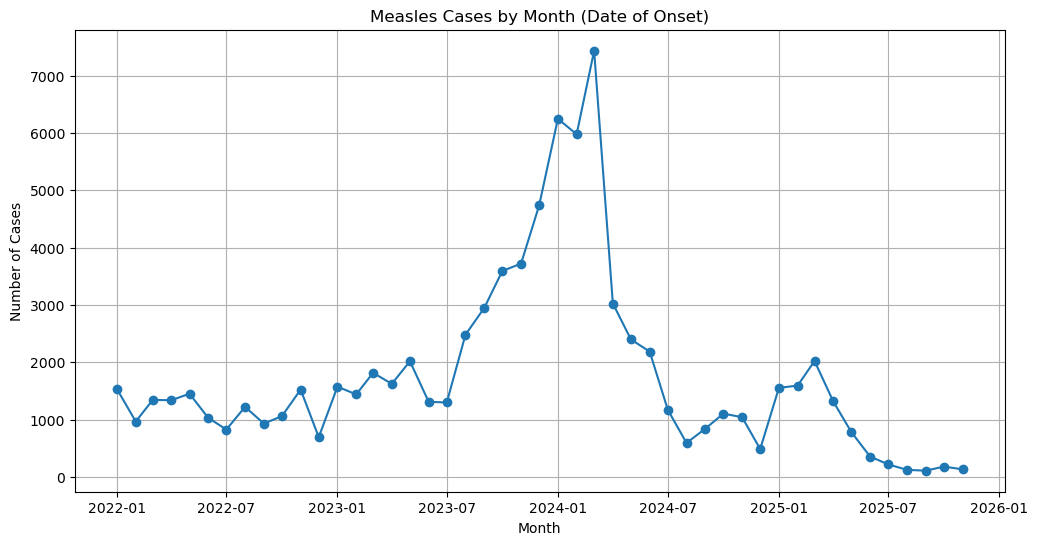

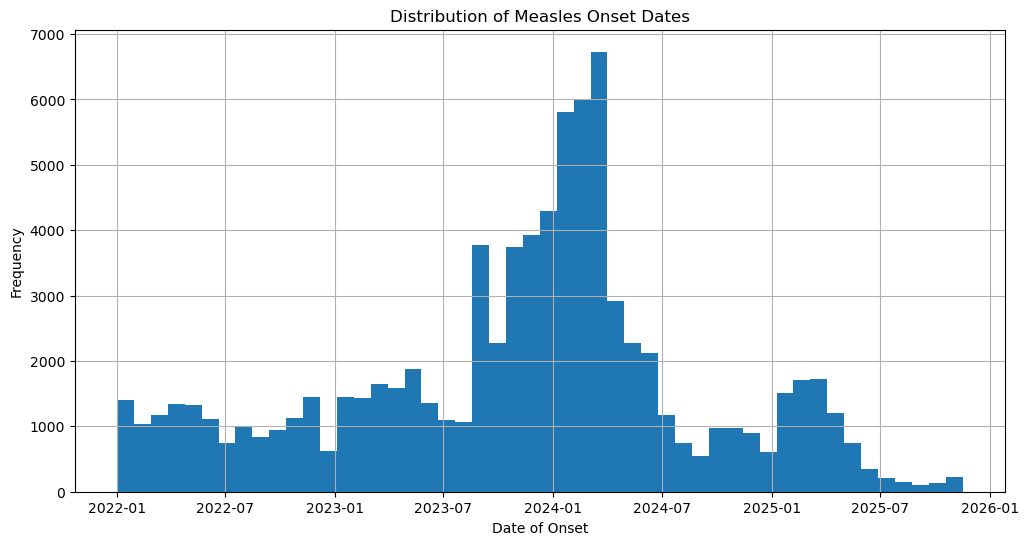

Cases by year:
 Onset_year
2022    13934
2023    28576
2024    32521
2025     8405
Name: count, dtype: int64
Cases by month:
 Onset_month
1     10911
2      9981
3     12620
4      7309
5      6654
6      4889
7      3521
8      4427
9      4834
10     5942
11     6426
12     5922
Name: count, dtype: int64
Weekly case counts (sample):
 Onset_year  Onset_week
2022        1             375
            2             214
            3             318
            4             457
            5             336
            6             303
            7             215
            8             137
            9             223
            10            297
dtype: int64


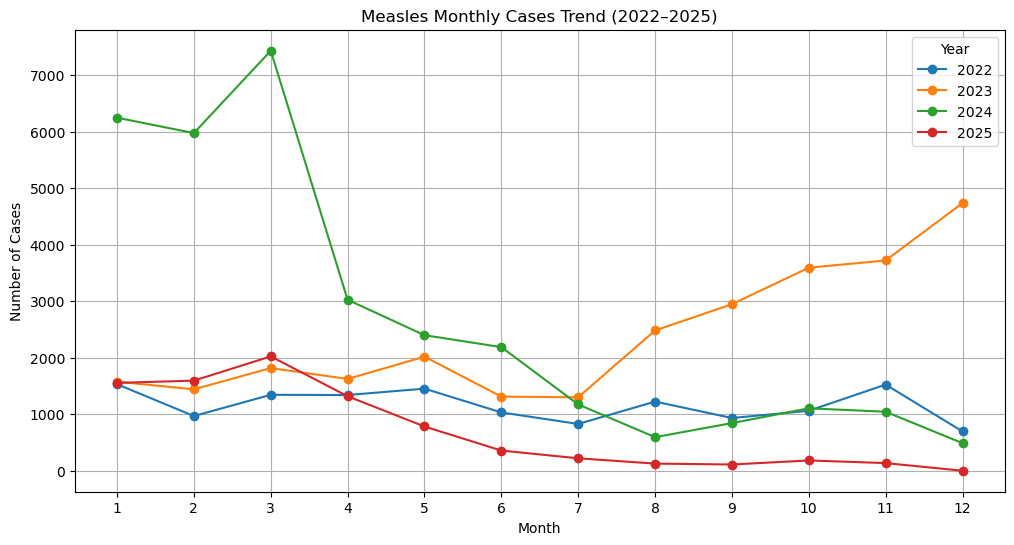

In [65]:
# Extract year and month
measles_df['Onset_year'] = measles_df['Date_onset'].dt.year
measles_df['Onset_month'] = measles_df['Date_onset'].dt.month

# Case counts by year-month
cases_by_month = measles_df.groupby(['Onset_year','Onset_month']).size().reset_index(name='Cases')
print(cases_by_month.head(5))  # show first 12 rows

import matplotlib.pyplot as plt

# Monthly epidemic curve
cases_by_month['Period'] = pd.to_datetime(cases_by_month['Onset_year'].astype(str) + '-' + cases_by_month['Onset_month'].astype(str) + '-01')
plt.figure(figsize=(12,6))
plt.plot(cases_by_month['Period'], cases_by_month['Cases'], marker='o')
plt.title("Measles Cases by Month (Date of Onset)")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.show()

#Histogram of Onset Dates
plt.figure(figsize=(12,6))
measles_df['Date_onset'].hist(bins=50)
plt.title("Distribution of Measles Onset Dates")
plt.xlabel("Date of Onset")
plt.ylabel("Frequency")
plt.show()
summary_table = pd.DataFrame({
    "Earliest Onset": [measles_df['Date_onset'].min()],
    "Latest Onset": [measles_df['Date_onset'].max()],
    "Median Onset": [measles_df['Date_onset'].median()],
    "Total Cases": [measles_df['Date_onset'].notna().sum()],
    "Missing Onset": [measles_df['Date_onset'].isna().sum()]
})
# Frequency by year
measles_df['Onset_year'] = measles_df['Date_onset'].dt.year
year_counts = measles_df['Onset_year'].value_counts().sort_index()
print("Cases by year:\n", year_counts)

# Frequency by month (aggregated across years)
measles_df['Onset_month'] = measles_df['Date_onset'].dt.month
month_counts = measles_df['Onset_month'].value_counts().sort_index()
print("Cases by month:\n", month_counts)

# Epidemic curve summary (weekly counts)
measles_df['Onset_week'] = measles_df['Date_onset'].dt.isocalendar().week
weekly_counts = measles_df.groupby(['Onset_year','Onset_week']).size()
print("Weekly case counts (sample):\n", weekly_counts.head(10))
# Pivot: months as x-axis, years as separate columns
cases_pivot = cases_by_month.pivot(index='Onset_month', columns='Onset_year', values='Cases').fillna(0)

# Plot multi-line chart
plt.figure(figsize=(12,6))
for year in cases_pivot.columns:
    plt.plot(cases_pivot.index, cases_pivot[year], marker='o', label=str(year))

plt.title("Measles Monthly Cases Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.xticks(range(1,13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

In [66]:
#cleaning of the Date Seen at Health Facility column.
# Convert safely
measles_df['Date_seen'] = pd.to_datetime(measles_df['Date Seen at Health facility'], errors='coerce')

# 1. Missing values
missing_seen = measles_df['Date_seen'].isna().sum()
print("Missing facility visit dates:", missing_seen)

# 2. Out-of-range values (outside 2022–2025)
out_of_range_seen = measles_df[(measles_df['Date_seen'] < '2022-01-01') | 
                               (measles_df['Date_seen'] > '2025-12-31')]
print("Out-of-range facility visit dates (sample):")
print(out_of_range_seen[['Date_seen']].head(10))

# 3. Invalid formats already coerced to NaT
invalid_seen = measles_df['Date Seen at Health facility'].shape[0] - measles_df['Date_seen'].notna().sum() - missing_seen
print("Invalid formats converted to NaT:", invalid_seen)
print("\nSummary of Date_seen after cleaning:")
print("Earliest date:", measles_df['Date_seen'].min())
print("Latest date:", measles_df['Date_seen'].max())
print("Median date:", measles_df['Date_seen'].median())
print("Unique dates:", measles_df['Date_seen'].nunique())
print("Total valid entries:", measles_df['Date_seen'].notna().sum())
measles_df['Seen_year'] = measles_df['Date_seen'].dt.year
measles_df['Seen_month'] = measles_df['Date_seen'].dt.to_period('M')

year_seen_counts = measles_df['Seen_year'].value_counts().sort_index()
month_seen_counts = measles_df['Seen_month'].value_counts().sort_index()

print("Cases by year (facility visit):\n", year_seen_counts)
print("Cases by month (facility visit):\n", month_seen_counts.head(12))


Missing facility visit dates: 7298
Out-of-range facility visit dates (sample):
      Date_seen
1149 2016-07-04
1159 2016-07-04
1160 2016-07-04
1161 2016-07-04
1162 2016-07-04
1163 2016-07-04
1164 2016-07-04
1165 2016-07-04
1166 2016-07-04
1167 2016-07-04
Invalid formats converted to NaT: 0

Summary of Date_seen after cleaning:
Earliest date: 2004-01-12 00:00:00
Latest date: 2034-10-31 00:00:00
Median date: 2024-01-17 00:00:00
Unique dates: 1476
Total valid entries: 76138
Cases by year (facility visit):
 Seen_year
2004.0        1
2014.0        3
2015.0       17
2016.0      258
2021.0        9
2022.0    11472
2023.0    23855
2024.0    32112
2025.0     8410
2034.0        1
Name: count, dtype: int64
Cases by month (facility visit):
 Seen_month
2004-01      1
2014-03      3
2015-05     10
2015-08      6
2015-09      1
2016-01      1
2016-02      9
2016-03     17
2016-04      2
2016-05      3
2016-06     62
2016-07    138
Freq: M, Name: count, dtype: int64


In [67]:
#A total of 289 records from 2004, 2014–2016, 2021, and even 2034. set them to NaT (missing). 
#since there are ~7k missing we will deal with this error together.
measles_df.loc[(measles_df['Date_seen'] < '2022-01-01') | 
               (measles_df['Date_seen'] > '2025-12-31'), 'Date_seen'] = pd.NaT

measles_df['Seen_year'] = measles_df['Date_seen'].dt.year
year_seen_counts = measles_df['Seen_year'].value_counts().sort_index()
print("Cases by year (facility visit):\n", year_seen_counts)

missing_seen = measles_df['Date_seen'].isna().sum()
print("Missing facility visit dates:", missing_seen)

Cases by year (facility visit):
 Seen_year
2022.0    11472
2023.0    23855
2024.0    32112
2025.0     8410
Name: count, dtype: int64
Missing facility visit dates: 7587


Summary of care-seeking interval:
count    75849.000000
mean         3.691070
std         18.884784
min       -365.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        367.000000
Name: Care_seeking_interval, dtype: float64
Mode interval: 2.0
Negative intervals (sample):
    Date_onset  Date_seen  Care_seeking_interval
983 2024-02-08 2024-02-07                   -1.0
984 2024-02-08 2024-02-07                   -1.0
985 2024-02-08 2024-02-07                   -1.0
987 2024-02-08 2024-02-07                   -1.0
995 2024-02-08 2024-02-07                   -1.0
Long delays (sample):
     Date_onset  Date_seen  Care_seeking_interval
646  2024-05-11 2024-06-14                   34.0
688  2024-04-02 2024-07-04                   93.0
4104 2024-02-08 2025-02-09                  367.0
4180 2024-01-10 2024-11-02                  297.0
4852 2024-01-02 2024-02-04                   33.0
Count of negative intervals: 3233
Count of long delays (>30 days): 945


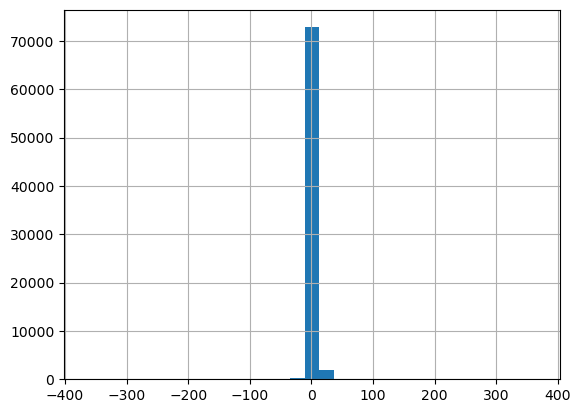

In [68]:
#calculate care-seeking interval and see the mean/mode interval, illogical intervals (negatives and long positive intervals) to clean them and to impute the ~7.5K missing date of health facility visit column
measles_df['Care_seeking_interval'] = (
    measles_df['Date_seen'] - measles_df['Date_onset']
).dt.days
print("Summary of care-seeking interval:")
print(measles_df['Care_seeking_interval'].describe())

print("Mode interval:", measles_df['Care_seeking_interval'].mode()[0])
negatives = measles_df[measles_df['Care_seeking_interval'] < 0]
long_delays = measles_df[measles_df['Care_seeking_interval'] > 30]

print("Negative intervals (sample):")
print(negatives[['Date_onset','Date_seen','Care_seeking_interval']].head())

print("Long delays (sample):")
print(long_delays[['Date_onset','Date_seen','Care_seeking_interval']].head())
measles_df['Care_seeking_interval'].hist(bins=31)
print("Count of negative intervals:", len(negatives))
print("Count of long delays (>30 days):", len(long_delays))

In [69]:
#Implausible care-seeking intervals (negative and >30 days) were treated as missing. 
#Missing facility visit dates were imputed using the median care-seeking interval derived from valid observations.
missing_interval = measles_df['Care_seeking_interval'].isna().sum()
print("Missing facility visit dates:", missing_interval)

# Flag anomalies
mask_problem = (
    measles_df['Date_seen'].isna() |
    (measles_df['Care_seeking_interval'] < 0) |
    (measles_df['Care_seeking_interval'] > 30)
)
#Compute the median interval from valid cases
median_interval = measles_df.loc[
    ~mask_problem, 'Care_seeking_interval'
].median()
print("Median interval used for imputation:", median_interval)

#Impute Date_seen for all flagged cases
measles_df['Date_seen_imputed'] = measles_df['Date_seen']

measles_df.loc[mask_problem, 'Date_seen_imputed'] = (
    measles_df.loc[mask_problem, 'Date_onset'] +
    pd.to_timedelta(median_interval, unit='D')
)
#Recalculate interval after imputation
measles_df['Care_seeking_interval_imputed'] = (
    measles_df['Date_seen_imputed'] - measles_df['Date_onset']
).dt.days

print(measles_df['Care_seeking_interval_imputed'].describe())


Missing facility visit dates: 7587
Median interval used for imputation: 2.0
count    83436.000000
mean         2.900427
std          3.174479
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         30.000000
Name: Care_seeking_interval_imputed, dtype: float64


Proportion seeking care within 3 days: 75.04%
Care_seeking_category
>48 hrs     31932
Same-day    10851
≤48 hrs     40653
Name: count, dtype: int64
Care_seeking_category
>48 hrs     0.382712
Same-day    0.130052
≤48 hrs     0.487236
Name: proportion, dtype: float64
Outcome_binary             0    1   CFR (%)
Care_seeking_category                      
>48 hrs                31666  266  0.833020
Same-day               10800   51  0.470003
≤48 hrs                40479  174  0.428013


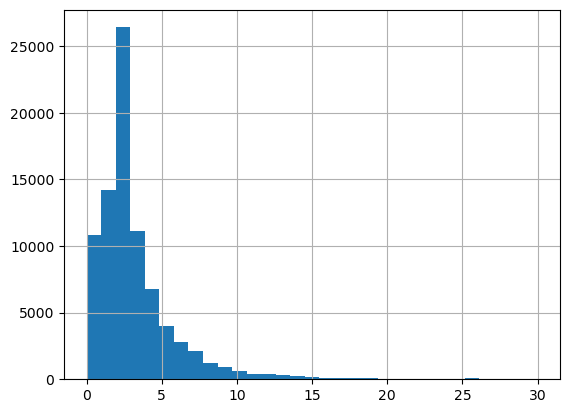

In [84]:
# Proportion seeking care within 3 days
within_3d = (measles_df['Care_seeking_interval_imputed'] <= 3).mean()
print(f"Proportion seeking care within 3 days: {within_3d:.2%}")
measles_df['Care_seeking_interval_imputed'].hist(bins=31)
# categorize the interval into same‑day(immediate care), ≤48 hours(timely care), and >48 hours (delayed care). That’s a very reasonable scheme:
def classify_interval(x):
    if x == 0:
        return "Same-day"
    elif x <= 2:
        return "≤48 hrs"
    else:
        return ">48 hrs"

measles_df['Care_seeking_category'] = measles_df['Care_seeking_interval_imputed'].apply(classify_interval)

# Frequency table
freq_table = measles_df['Care_seeking_category'].value_counts().sort_index()
print(freq_table)

# Relative proportions
prop_table = measles_df['Care_seeking_category'].value_counts(normalize=True).sort_index()
print(prop_table)
# Cross-tabulation of care-seeking category by outcome
care_outcome = pd.crosstab(measles_df['Care_seeking_category'], measles_df['Outcome_binary'])

# Add CFR (%) column for each category
care_outcome['CFR (%)'] = (care_outcome[1] / (care_outcome[0] + care_outcome[1])) * 100

print(care_outcome)


In [71]:
# Frequency table of Measles IgM results
igm_freq = measles_df['Measles IgM'].value_counts(dropna=False)
print(igm_freq)

# Relative proportions
igm_prop = measles_df['Measles IgM'].value_counts(normalize=True, dropna=False)
print(igm_prop)
# Cross-tab to check relationship
# Cross-tab: Measles IgM vs specimen collection date missingness
# cross‑tab specifically between Measles IgM values and whether the specimen collection date is missing (NaN). 
#That way you can confirm if “Unknown” IgM corresponds to no specimen collected.
ctab = pd.crosstab(
    measles_df['Measles IgM'],
    measles_df['Date specimen collected'].isna(),
    margins=True,
    normalize='index'  # optional: gives row percentages
)

print(ctab)
#Unknown (9) rows show nearly all True (missing specimen date), 
#then missing IgM is due to non‑collection.

Measles IgM
9    60804
2    14738
1     6480
4     1060
3      254
5      100
Name: count, dtype: int64
Measles IgM
9    0.728750
2    0.176638
1    0.077664
4    0.012704
3    0.003044
5    0.001199
Name: proportion, dtype: float64
Date specimen collected     False      True
Measles IgM                                
1                        0.991975  0.008025
2                        0.999050  0.000950
3                        0.996063  0.003937
4                        0.995283  0.004717
5                        0.990000  0.010000
9                        0.000000  1.000000
All                      0.270375  0.729625


In [72]:
# Map IgM codes into three categories: Positive, Negative, Not Done
igm_map_simple = {
    1: "Positive",
    2: "Negative",
    3: "Not Done",   # Indeterminate
    4: "Not Done",   # Explicitly not done
    5: "Not Done",   # Pending
    9: "Not Done"    # Unknown
}

measles_df['Measles_IgM_clean'] = measles_df['Measles IgM'].map(igm_map_simple)

# Frequency table of cleaned categories
print(measles_df['Measles_IgM_clean'].value_counts())
print(measles_df['Measles_IgM_clean'].value_counts(normalize=True))

Measles_IgM_clean
Not Done    62218
Negative    14738
Positive     6480
Name: count, dtype: int64
Measles_IgM_clean
Not Done    0.745697
Negative    0.176638
Positive    0.077664
Name: proportion, dtype: float64


In [73]:
#Missing specimen dates are not random — they correspond to “Unknown” or “Not Done” IgM codes.
# Check missingness
print(measles_df['Date specimen collected'].isna().sum())

# Count of non-missing
print(measles_df['Date specimen collected'].notna().sum())
# Earliest and latest specimen collection dates
print("Min:", measles_df['Date specimen collected'].min())
print("Max:", measles_df['Date specimen collected'].max())


60877
22559
Min: 2022-01-01 00:00:00
Max: 2025-11-18 00:00:00


count    22559.000000
mean         4.010816
std          5.316457
min        -29.000000
25%          1.000000
50%          3.000000
75%          5.000000
max        253.000000
Name: Specimen_delay, dtype: float64


<Axes: >

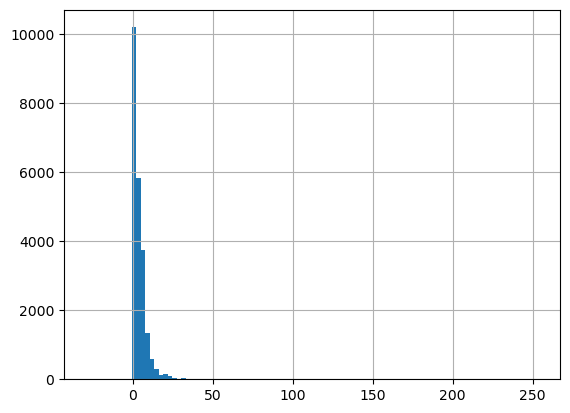

In [74]:
measles_df['Specimen_delay'] = (
    measles_df['Date specimen collected'] - measles_df['Dateof onset']
).dt.days
print(measles_df['Specimen_delay'].describe())
measles_df['Specimen_delay'].hist(bins=100)

count    21131.000000
mean         3.101936
std          2.388453
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: Specimen_delay, dtype: float64


<Axes: >

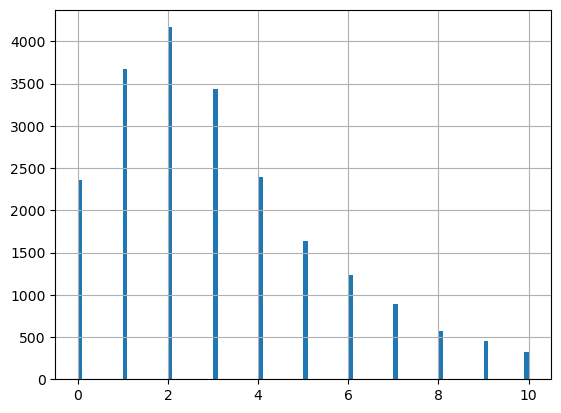

In [75]:
mask_specimen_problem = (
    (measles_df['Specimen_delay'] < 0) |
    (measles_df['Specimen_delay'] > 10)
)

measles_df.loc[mask_specimen_problem, 'Specimen_delay'] = pd.NA
print(measles_df['Specimen_delay'].describe())

measles_df['Specimen_delay'].hist(bins=100)

In [76]:
# Gross missing and non-missing counts for lab result date
missing_count = measles_df['DateLab Sent Out results'].isna().sum()
non_missing_count = measles_df['DateLab Sent Out results'].notna().sum()

print("Missing lab result dates:", missing_count)
print("Non-missing lab result dates:", non_missing_count)

# Create flags
measles_df['Specimen_date_flag'] = measles_df['Date specimen collected'].notna().astype(int)
measles_df['Lab_result_date_flag'] = measles_df['DateLab Sent Out results'].notna().astype(int)

# Cross-tab: specimen date vs lab result date
ctab = pd.crosstab(
    measles_df['Specimen_date_flag'],
    measles_df['Lab_result_date_flag'],
    margins=True
)

print(ctab)

Missing lab result dates: 38992
Non-missing lab result dates: 44444
Lab_result_date_flag      0      1    All
Specimen_date_flag                       
0                     32099  28778  60877
1                      6893  15666  22559
All                   38992  44444  83436


count    15666.000000
mean         6.957551
std         68.097380
min      -8397.000000
25%          4.000000
50%          6.000000
75%          8.000000
max        332.000000
Name: Lab_turnaround_time, dtype: float64


<Axes: >

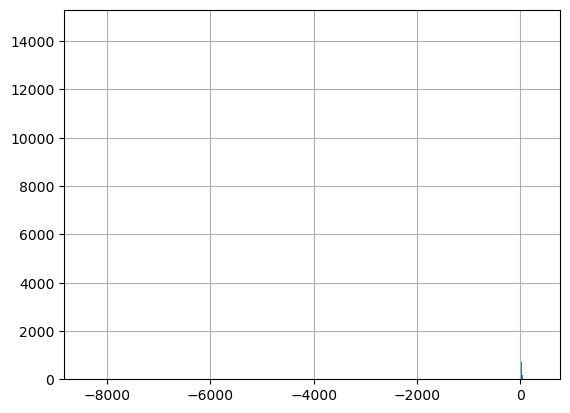

In [77]:
# Calculate turnaround time only where both dates are present
measles_df['Lab_turnaround_time'] = (
    measles_df['DateLab Sent Out results'] - measles_df['Date specimen collected']
).dt.days

# Mask invalid cases (missing specimen or lab result date)
mask_invalid = measles_df['Specimen_date_flag'] == 0
mask_invalid |= measles_df['Lab_result_date_flag'] == 0

measles_df.loc[mask_invalid, 'Lab_turnaround_time'] = pd.NA

# Quick summary of valid turnaround times
print(measles_df['Lab_turnaround_time'].describe())
measles_df['Lab_turnaround_time'].hist(bins=500)

count    15210.000000
mean         6.701381
std          4.638710
min          0.000000
25%          4.000000
50%          5.000000
75%          8.000000
max         30.000000
Name: Lab_turnaround_time, dtype: float64


<Axes: >

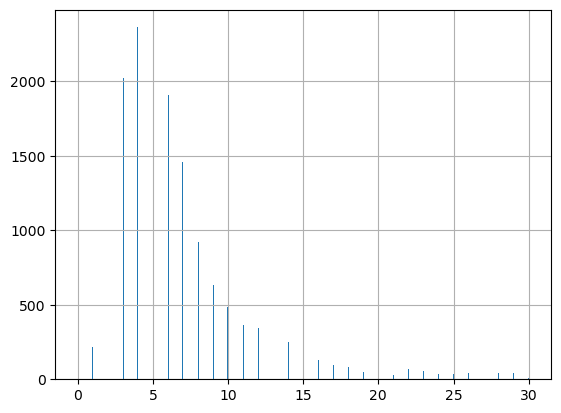

In [78]:
mask_anomaly = (measles_df['Lab_turnaround_time'] < 0) | (measles_df['Lab_turnaround_time'] > 30)
measles_df.loc[mask_anomaly, 'Lab_turnaround_time'] = pd.NA
# Quick summary of valid turnaround times
print(measles_df['Lab_turnaround_time'].describe())
measles_df['Lab_turnaround_time'].hist(bins=500)

In [79]:
# Frequency table of raw FC column
fc_freq = measles_df['FC'].value_counts(dropna=False)
print(fc_freq)

# Relative proportions
fc_prop = measles_df['FC'].value_counts(normalize=True, dropna=False)
print(fc_prop)

FC
2    60805
4    15798
1     6478
3      254
5      101
Name: count, dtype: int64
FC
2    0.728762
4    0.189343
1    0.077640
3    0.003044
5    0.001211
Name: proportion, dtype: float64


In [85]:
fc_map = {
    1: "Confirmed by lab",
    2: "Confirmed by epi linkage",
    3: "Compatible/clin. no specimen",
    4: "Discarded - IgM negative",
    5: "Pending lab result"
}

measles_df['Final_classification'] = measles_df['FC'].map(fc_map)
print(measles_df['Final_classification'])
print(measles_df['Final_classification'].value_counts())
print(measles_df['Final_classification'].value_counts(normalize=True))
pd.crosstab(measles_df['Final_classification'],
            measles_df['Measles_IgM_clean'],
            margins=True)
# Cross-tabulation of final classification by outcome
fc_outcome = pd.crosstab(measles_df['Final_classification'], measles_df['Outcome_binary'])

# Add CFR (%) column
fc_outcome['CFR (%)'] = (fc_outcome[1] / (fc_outcome[0] + fc_outcome[1])) * 100

print(fc_outcome)

0        Discarded - IgM negative
1        Discarded - IgM negative
2        Discarded - IgM negative
3                Confirmed by lab
4        Discarded - IgM negative
                   ...           
83431    Discarded - IgM negative
83432    Discarded - IgM negative
83433    Discarded - IgM negative
83434    Discarded - IgM negative
83435    Discarded - IgM negative
Name: Final_classification, Length: 83436, dtype: object
Final_classification
Confirmed by epi linkage        60805
Discarded - IgM negative        15798
Confirmed by lab                 6478
Compatible/clin. no specimen      254
Pending lab result                101
Name: count, dtype: int64
Final_classification
Confirmed by epi linkage        0.728762
Discarded - IgM negative        0.189343
Confirmed by lab                0.077640
Compatible/clin. no specimen    0.003044
Pending lab result              0.001211
Name: proportion, dtype: float64
Outcome_binary                    0    1   CFR (%)
Final_classification  

In [81]:
# 1. Save full dataset (all original + cleaned columns)
#measles_df.to_excel("measles_cleaned_full.xlsx", index=False)

In [82]:
# Define the selected variables
selected_vars = [
    'Outcome_clean',
    'Age_final_imputed',
    'Age_group',
    'Sex_clean',
    'Vx_status',
    'Region_clean',
    'Zone',
    'Facility_type_final',
    'Onset_year',
    'Onset_month',
    'Care_seeking_interval_imputed',
    'Care_seeking_category',
    'Measles_IgM_clean',
    'Specimen_delay',
    'Lab_turnaround_time',
    'Final_classification'
]

# Save only these columns into a new Excel file
measles_df[selected_vars].to_excel("measles_selected_cleaned.xlsx", index=False)